# picofold tutorial: Protein folding from scratch

Build [picofold.py](https://github.com/daveyburke/picofold/blob/main/picofold.py) up piece by piece: a ~200-line protein structure predictor in the spirit of SimpleFold (a plain transformer + flow matching, no AlphaFold machinery). Task: given 16 amino acids, generate the 3D positions of their 16 C-alpha atoms. Train on ~47k 16-residue fragments from CATH S40 / Protein Data Bank.

|   | Contents |
|---|---|
| 1 | Meet the data
| 2 | Rotations and the scoreboard
| 3 | Flow matching: noise → structure on a straight line
| 4 | The model: one token per residue (what + where + when)
| 5 | Train
| 6 | Generate: Euler → Euler–Maruyama

👉 **Runtime → Change runtime type → T4 GPU** (or better) before running. Every cell runs top to bottom; code is consistent with `picofold.py`.

In [1]:
import math
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import plotly.graph_objects as go   # interactive 3D: drag to rotate the proteins

torch.manual_seed(42); random.seed(42)   # fixed seeds so the numbers match the talk
device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print("device:", device)

# Hyperparameters (identical to picofold.py)
L = 16               # residues per window (must match the data file)
D_MODEL = 128        # width of the transformer
N_LAYER = 4          # depth of the transformer
N_HEAD = 4           # attention heads per layer
BATCH = 256          # batch size
TRAIN_STEPS = 10000  # training steps (a few minutes on a T4; drop to ~2000 for a quick live demo)
LR = 1e-3            # learning rate, 1e-3 is a good default
SCALE = 16.0         # divide coordinates (Angstroms) by this so they're roughly unit size
SAMPLE_STEPS = 200   # steps when generating a structure
TAU = 0.3            # fresh noise factor during sampling, 0.3 is a good default, helps with stability
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY" # amino acid tokenization: 20 letters -> ids 0..19

device: cuda


## 1. Meet the data
A protein is a string over a 20-letter alphabet that folds into a 3D shape. We keep **one atom per residue**, the
C-alpha (the backbone "knuckle"), so a structure is just a `(16, 3)` array of 3D coordinates in Angstroms (Å).

The repo has the data (`train_data.txt`, `test_data.txt`: ~47k / ~5k fragments cut from real proteins in the Protein
Data Bank) and the finished `picofold.py` we're working towards. First, let's look at the training data...

In [2]:
import os
# Clone once; safe to re-run (if we're already inside the repo, do nothing)
if not os.path.exists('train_data.txt'):
    if not os.path.exists('picofold'):
        !git clone -q https://github.com/daveyburke/picofold.git
    os.chdir('picofold')

In [3]:
# Each line: domain_id, 16-letter sequence, then 16 x (x, y, z) in Angstroms = 48 numbers
line = open('train_data.txt').readline()
print("Line:", line)

line = line.split()
print("domain:  ", line[0])
print("sequence:", line[1])
print("first 3 C-alphas (x y z):", line[2:5], line[5:8], line[8:11], "...")
print("numbers per line:", len(line) - 2, "= 16 residues x 3 coords")

Line: 152lA00 MNCFEMLRCDEGLRLK -10.00 3.64 4.25 -10.26 0.15 2.89 -8.17 -2.95 2.73 -6.30 -1.86 -0.35 -5.49 1.53 1.12 -4.36 -0.07 4.27 -2.05 -2.33 2.25 -0.77 0.47 0.08 0.01 2.40 3.24 2.11 -0.42 4.68 3.81 -1.77 1.57 4.45 1.46 -0.18 5.54 1.26 -3.83 8.89 0.39 -5.34 9.61 -0.07 -9.03 12.96 -1.82 -8.37

domain:   152lA00
sequence: MNCFEMLRCDEGLRLK
first 3 C-alphas (x y z): ['-10.00', '3.64', '4.25'] ['-10.26', '0.15', '2.89'] ['-8.17', '-2.95', '2.73'] ...
numbers per line: 48 = 16 residues x 3 coords


In [4]:
def load(path):
    rows = [line.split() for line in open(path)] # each line is "domain_id SEQUENCE x1 y1 z1 ... x16 y16 z16"
    seqs = [[AMINO_ACIDS.index(a) for a in r[1]] for r in rows]  # letters -> integer token ids
    coords = [[float(v) for v in r[2:]] for r in rows] # (N, L*3)
    return torch.tensor(seqs), torch.tensor(coords).view(-1, L, 3)  # (N, L), (N, L, 3)

train_seq, train_xyz = load('train_data.txt')
test_seq, test_xyz = load('test_data.txt')
print("train:", tuple(train_seq.shape), tuple(train_xyz.shape))
print("test: ", tuple(test_seq.shape), tuple(test_xyz.shape))

decode = lambda ids: ''.join(AMINO_ACIDS[i] for i in ids)  # token ids -> letters, handy for printing
print("round trip:", decode(train_seq[0].tolist()))

train: (46859, 16) (46859, 16, 3)
test:  (5335, 16) (5335, 16, 3)
round trip: MNCFEMLRCDEGLRLK


In [5]:
# Sanity check #1: physics. Neighbouring C-alphas are joined by a rigid peptide unit, so they should ALWAYS be ~3.8 A apart.
d_next = (train_xyz[:, 1:] - train_xyz[:, :-1]).norm(dim=-1)  # (N, L-1) distance from residue i to i+1
print(f"C-alpha to C-alpha: {d_next.mean():.2f} +/- {d_next.std():.2f} A")   # expect ~3.80 +/- ~0.05

C-alpha to C-alpha: 3.81 +/- 0.05 A


Two classic local shapes: the **alpha-helix** (a tight right-handed spiral, 3.6 residues per turn) and the
**beta-strand** (stretched out, zig-zag). Here's one of each from the training set.

In [6]:
helix_idx, strand_idx = 9351, 28586   # hand-picked: the most helical and the most extended training fragments
print("helix: ", decode(train_seq[helix_idx].tolist()))
print("strand:", decode(train_seq[strand_idx].tolist()))

def ca_trace(xyz, seq=None, name='', color=None):
    # One 3D line-and-dots trace for a (L, 3) C-alpha chain; hover shows residue number + amino acid
    xyz = torch.as_tensor(xyz).tolist()
    labels = [f"{i} {AMINO_ACIDS[a]}" for i, a in enumerate(seq.tolist())] if seq is not None else None
    return go.Scatter3d(x=[p[0] for p in xyz], y=[p[1] for p in xyz], z=[p[2] for p in xyz], name=name, text=labels,
                        mode='lines+markers', line=dict(width=6, color=color),
                        marker=dict(size=5, color=list(range(L)), colorscale='Viridis'))  # colour = N -> C terminus

def show(*traces, title=''):
    fig = go.Figure(traces)
    fig.update_layout(title=title, height=450, margin=dict(l=0, r=0, t=40, b=0),
                      scene=dict(aspectmode='data'))  # equal axes, so a helix looks like a helix
    fig.show()

show(ca_trace(train_xyz[helix_idx], train_seq[helix_idx], 'helix', 'crimson'),
     ca_trace(train_xyz[strand_idx] + torch.tensor([25., 0, 0]), train_seq[strand_idx], 'strand', 'steelblue'),
     title='Drag me: an alpha-helix and a beta-strand (16 C-alphas each)')

helix:  LSLLTQNNLNKSQSAL
strand: FSVYGGLKLRQNKNYL


## 2. Rotations and the scoreboard
A protein floating in water has no "up". The same structure spun around is still the same structure. So:
1. During training we'll spin every example to a **random orientation** (data augmentation → rotation invariance).
2. We'll **score** with internal distances, which don't care about orientation.

In [7]:
def normalize(v):
    n = math.sqrt(sum(c * c for c in v))
    return [c / n for c in v]

def random_rotation_matrix():
    # Gram-Schmidt on random vectors: pick a random x axis, a y axis perpendicular to it, and z = x cross y
    x = normalize([random.gauss(0, 1) for _ in range(3)]) # new x axis: a random direction
    y = [random.gauss(0, 1) for _ in range(3)]
    d = sum(a * b for a, b in zip(x, y))              # dot product: how much of y points along x
    y = normalize([b - d * a for a, b in zip(x, y)])  # new y axis: remove that part
    z = [x[1]*y[2] - x[2]*y[1], x[2]*y[0] - x[0]*y[2], x[0]*y[1] - x[1]*y[0]]  # new z axis: x y cross product
    return [[x[i], y[i], z[i]] for i in range(3)]     # transpose x, y, z to columns of 3x3 matrix

R = torch.tensor(random_rotation_matrix())
print("R @ R.T = I ?", torch.allclose(R @ R.T, torch.eye(3), atol=1e-6))

helix = train_xyz[helix_idx]
spun = helix @ R  # (L, 3) @ (3, 3): rotate every residue
show(ca_trace(helix, name='original', color='crimson'), ca_trace(spun, name='rotated', color='orange'),
     title='Same helix, two orientations')

R @ R.T = I ? True


**lDDT** (0..1, higher is better; AlphaFold's go-to local score): for every residue pair that's within 15 Å in the
true structure, is the predicted distance within 0.5, 1, 2, 4 Å of the true one? Average the pass rate.
**dRMSD** (Å, lower is better): root-mean-square error over all pairwise distances. More sensitive to outliers (squared error). Neither needs superposition.

In [8]:
LDDT_THRESHOLDS = (0.5, 1.0, 2.0, 4.0) # Angstroms
def lddt(pred, true, cutoff=15.0):
    # For each pair of residues within `cutoff` Angstroms in the true structure,
    # check whether the predicted distance is within each threshold of the true one
    passed, total = 0, 0
    for i in range(len(true)):
        for j in range(i + 1, len(true)):
            d_true = math.dist(true[i], true[j])
            if d_true >= cutoff:
                continue  # only score LOCAL geometry
            err = abs(math.dist(pred[i], pred[j]) - d_true)
            passed += sum(err < thr for thr in LDDT_THRESHOLDS)
            total += len(LDDT_THRESHOLDS)
    return passed / total

def drmsd(pred, true):
    # Root-mean-square error over all pairwise distances (Angstroms). Like RMSD, but no superposition needed.
    sq_errors = [(math.dist(pred[i], pred[j]) - math.dist(true[i], true[j])) ** 2
                 for i in range(len(true)) for j in range(i + 1, len(true))]
    return math.sqrt(sum(sq_errors) / len(sq_errors))

def avg(metric, preds, trues):
    preds, trues = preds.tolist(), trues.tolist()   # (N, L, 3) tensors -> nested lists
    return sum(metric(p, t) for p, t in zip(preds, trues)) / len(preds)

# Sanity checks: perfect = 1.0 / 0.0, and rotation doesn't matter
print("lDDT(helix, helix)   =", lddt(helix.tolist(), helix.tolist()))
print("lDDT(rotated, helix) =", round(lddt(spun.tolist(), helix.tolist()), 4))
print("lDDT(strand, helix)  =", round(lddt(train_xyz[strand_idx].tolist(), helix.tolist()), 3), " <- very wrong shape")

lDDT(helix, helix)   = 1.0
lDDT(rotated, helix) = 1.0
lDDT(strand, helix)  = 0.195  <- very wrong shape


## 3. Flow matching: noise → structure on a straight line
Treat folding like text-to-image: start from random noise and gradually turn it into a structure, conditioned on the
sequence. Flow matching's recipe is quite simple in fact:

$$x_t = t\,x_1 + (1-t)\,x_0 \qquad x_0 \sim \mathscr{N}(0, I)\ \text{(noise)},\quad x_1 = \text{true structure}$$

`t` is the "progress bar": pure noise at 0, the structure at 1. The velocity along that line is constant:
$\;v = dx_t/dt = x_1 - x_0$. **The network's one job: given $x_t$, $t$ and the sequence, predict $v$.**

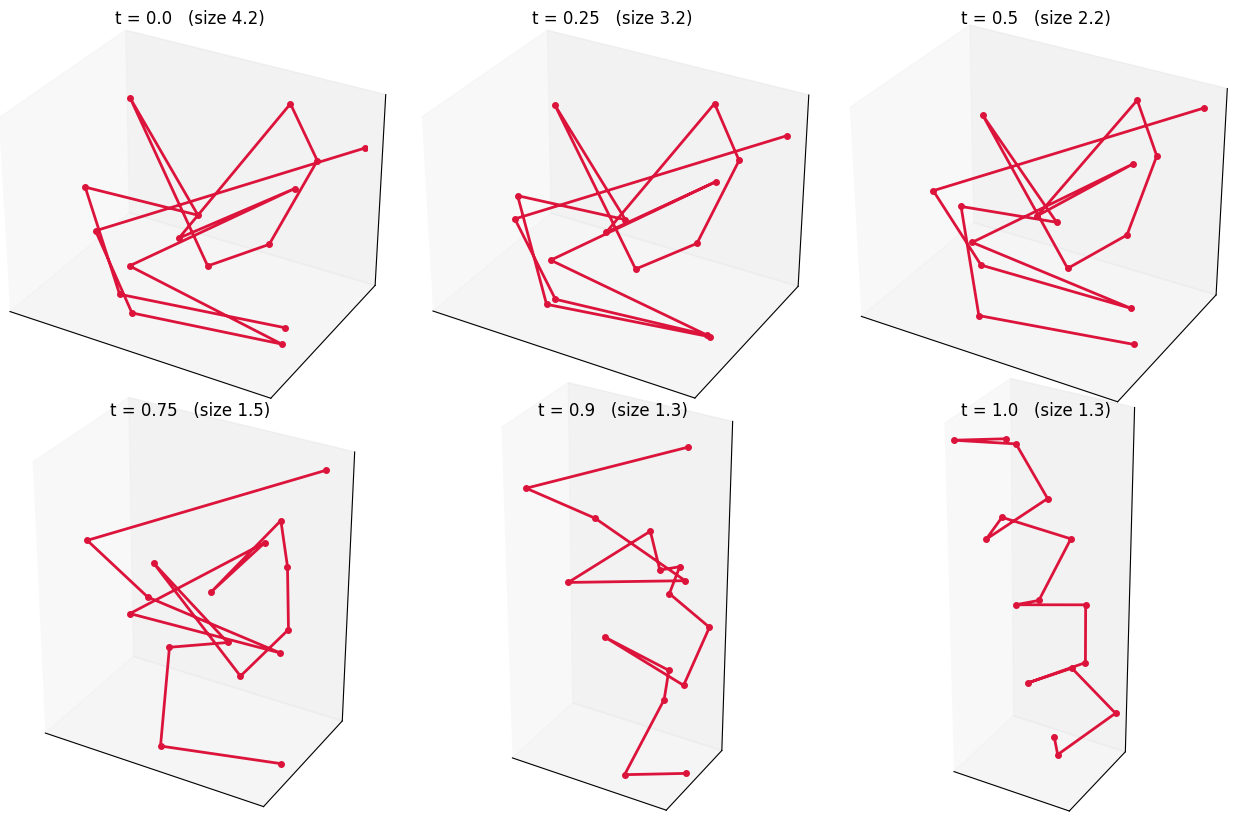

noise std 1.10 vs structure std 0.25: the 'signal' is small, which is why late t matters


In [9]:
# Watch one helix emerge from noise along the straight line (coordinates in SCALE units, i.e. roughly unit size)
fig = plt.figure(figsize=(13, 8))
x1 = helix / SCALE                 # (L, 3) the structure
x0 = torch.randn_like(x1)          # (L, 3) the noise
ts = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]   # six snapshots along the line
for k, t in enumerate(ts):
    x_t = t * x1 + (1 - t) * x0    # the interpolation, that's it
    ax = fig.add_subplot(2, 3, k + 1, projection='3d')
    ax.plot(*x_t.T, '-o', color='crimson', ms=4, lw=2)
    # Each panel is zoomed to fit tightly, with the same scale on all 3 axes so shapes aren't distorted.
    # Watch the size in the title: the cloud shrinks ~3x as the noise fades (the structure is smaller than the noise).
    lo, hi = x_t.min(dim=0).values, x_t.max(dim=0).values
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((hi - lo).tolist(), zoom=1.2)   # box proportional to the data = equal scaling, no wasted space
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(f"t = {t}   (size {(hi - lo).max():.1f})")
plt.tight_layout(); plt.show()

print(f"noise std {x0.std():.2f} vs structure std {x1.std():.2f}: the 'signal' is small, which is why late t matters")

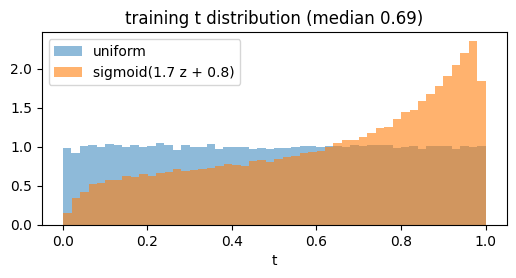

In [10]:
# Which t do we train on? The fine detail near t=1 (exact 3.8 A spacing,
# helix pitch) is what matters, so picofold samples t from a logit-normal skewed towards 1.
t_skew = torch.sigmoid(torch.randn(100_000) * 1.7 + 0.8)
plt.figure(figsize=(6, 2.5))
plt.hist(torch.rand(100_000), bins=50, alpha=0.5, density=True, label='uniform')
plt.hist(t_skew, bins=50, alpha=0.6, density=True, label='sigmoid(1.7 z + 0.8)')
plt.xlabel('t'); plt.legend(); plt.title(f"training t distribution (median {t_skew.median():.2f})"); plt.show()

## 4. The model: one token per residue
The transformer body is completely standard. What's specific to folding is **how we make the tokens**.
Each residue's token is the **sum** of three embeddings:

| | what | how | shape |
|---|---|---|---|
| **what** it is | amino acid | `nn.Embedding(20, d)` lookup, exactly like word tokens | (B, L, d) |
| **where** it is | noisy 3D coords $x_t$ | `nn.Linear(3, d)`: a continuous input, not a token! | (B, L, d) |
| **when** we are | noise level $t$ | sinusoids → MLP, shared by all residues | (B, d) → broadcast |

Plus **RoPE** inside attention so the model knows residue *order* along the chain (attention alone is permutation-symmetric). LayerNorm (vs RMSNorm) is a carry over from SimpleFold that used AdaLN. Output: a 3D velocity per residue.

In [11]:
# The model. Everything here is a standard transformer (quick scroll), except step 1 of forward():
# how each residue becomes a token. We'll unpack that line in the next two cells.
def attention(q, k, v): # each (B, L, H, hd)
    q, k, v = (z.transpose(1, 2) for z in (q, k, v))             # (B, H, L, hd) one attention problem per head
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(q.shape[-1])  # (B, H, L, L) every residue pair, scaled
    weights = torch.softmax(scores, dim=-1)                      # (B, H, L, L) each row sums to 1. No causal mask!
    return (weights @ v).transpose(1, 2).flatten(2)              # (B, L, d) heads back in place, concatenated

def rope(x, cos, sin):
    # Rotary position embedding: rotate pairs of channels by an angle proportional to the residue index, so
    # q.k depends on the RELATIVE position (i - j) along the chain. Without this, shuffling the residues would just
    # shuffle the output: the model couldn't tell the N-terminus from the C-terminus.
    x1, x2 = x.chunk(2, dim=-1)  # split half implementation; each (B, L, H, hd/2)
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)  # (B, L, H, hd)

### Model: a transformer that maps (sequence, noisy coords, t) -> velocity ###
# Dims: B = batch, L = amino_acid_seq_size, d = D_MODEL, H = N_HEAD, hd = head_dim
class PicoFold(nn.Module):
    def __init__(self):
        super().__init__()
        # --- The three problem-specific embeddings (the interesting part) ---
        self.aa_embed = nn.Embedding(len(AMINO_ACIDS), D_MODEL)  # WHAT: 20 amino acids -> d
        self.coord_in = nn.Linear(3, D_MODEL)                    # WHERE: (x, y, z) -> d
        self.time_mlp = nn.Sequential(nn.Linear(D_MODEL, D_MODEL), nn.SiLU(), nn.Linear(D_MODEL, D_MODEL))  # WHEN

        # --- A completely standard pre-norm transformer: attention (QK-norm, RoPE) + SwiGLU MLP ---
        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm1': nn.LayerNorm(D_MODEL),
                'qkv': nn.Linear(D_MODEL, 3 * D_MODEL, bias=False),
                'q_norm': nn.RMSNorm(D_MODEL // N_HEAD),  # QK-norm: keeps attention logits from blowing up
                'k_norm': nn.RMSNorm(D_MODEL // N_HEAD),
                'proj': nn.Linear(D_MODEL, D_MODEL),
                'norm2': nn.LayerNorm(D_MODEL),
                'gate': nn.Linear(D_MODEL, 4 * D_MODEL, bias=False),
                'up': nn.Linear(D_MODEL, 4 * D_MODEL, bias=False),
                'down': nn.Linear(4 * D_MODEL, D_MODEL, bias=False),
            }) for _ in range(N_LAYER)
        ])

        # --- Output: one 3D velocity per residue ---
        self.final_norm = nn.LayerNorm(D_MODEL, elementwise_affine=False)  # no affine part (won't undo the zero init)
        self.out = nn.Linear(D_MODEL, 3)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)  # start out predicting zero velocity
        self.head_dim = D_MODEL // N_HEAD

        # Precompute RoPE angle for each (position, frequency) pair
        theta = 1.0 / (100.0 ** (torch.arange(0, self.head_dim, 2) / self.head_dim))  # theta_i = 1 / 100^2i/d, fast to slow
        angles = torch.arange(L)[:, None] * theta[None, :]  #  m * theta_i (L, hd/2)
        self.register_buffer('cos', angles.cos()[None, :, None, :])  # (1, L, 1, hd/2)
        self.register_buffer('sin', angles.sin()[None, :, None, :])  # (1, L, 1, hd/2)

    def forward(self, seq, x_t, t): # seq: amino-acid ids (B, L); x_t: noisy coords (B, L, 3); t: noise level (B,)
        # 1. Each residue's token is the sum of its amino acid embedding, its noisy coordinates, and timestep embedding
        t = self.time_mlp(timestep_embedding(t, D_MODEL))  # sinusoidal frequencies -> MLP (B, d)
        h = self.aa_embed(seq) + self.coord_in(x_t) + t[:, None, :]  # (B, L, d)

        # 2. Transformer blocks
        B = h.shape[0]
        for block in self.blocks:
            # a) Multi-head attention, with QK-norm and RoPE. Bidirectional (no causal mask: every residue sees every other)
            q, k, v = block['qkv'](block['norm1'](h)).view(B, L, 3, N_HEAD, self.head_dim).unbind(2)  # each (B, L, H, hd)
            q, k = rope(block['q_norm'](q), self.cos, self.sin), rope(block['k_norm'](k), self.cos, self.sin)
            h = h + block['proj'](attention(q, k, v))  # (B, L, d)

            # b) SwiGLU feed-forward network
            n = block['norm2'](h)  # (B, L, d)
            h = h + block['down'](nn.functional.silu(block['gate'](n)) * block['up'](n))  # (B, L, 4d) inside, (B, L, d) out

        return self.out(self.final_norm(h))  # (B, L, 3) velocity

model = PicoFold().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,087,875


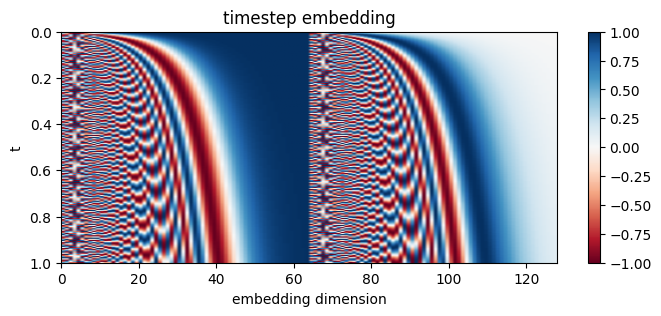

In [12]:
def timestep_embedding(t, dim):
    # Turn scalar t into sines and cosines at many frequencies, to more easily tell nearby noise levels apart
    half = dim // 2
    freqs = 10000.0 ** (-torch.arange(half, device=t.device) / half)  # (d/2,) from 1 down to ~0.0001
    angles = 1000 * t[:, None] * freqs[None, :]  # (B, d/2); the 1000 scales t into the range these frequencies suit
    return torch.cat([torch.cos(angles), torch.sin(angles)], dim=-1)  # (B, d)

# What does it look like? Each row is one t. Fast frequencies (left) separate t=0.70 from t=0.71;
# slow ones (right) give a smooth "rough position" signal. A single raw scalar t is much harder for an MLP to use.
t_grid = torch.linspace(0, 1, 200)
plt.figure(figsize=(8, 3))
plt.imshow(timestep_embedding(t_grid, D_MODEL), aspect='auto', cmap='RdBu', extent=[0, D_MODEL, 1, 0])
plt.xlabel('embedding dimension'); plt.ylabel('t'); plt.title('timestep embedding'); plt.colorbar(); plt.show()

In [13]:
# The token recipe on a tiny batch, using the model's own (still untrained) layers, exactly as in forward() step 1
B = 2
seq = train_seq[:B].to(device)                        # (B, L) integer amino acid ids
x_t = torch.randn(B, L, 3, device=device)             # (B, L, 3) noisy coordinates
t = torch.rand(B, device=device)                      # (B,) noise levels

aa = model.aa_embed(seq)                              # (B, L, d)  WHAT: amino acid lookup table
xyz = model.coord_in(x_t)                             # (B, L, d)  WHERE: Linear(3 -> d) on the coordinates
tt = model.time_mlp(timestep_embedding(t, D_MODEL))   # (B, d)     WHEN: sinusoids -> small MLP, one vector per structure
h = aa + xyz + tt[:, None, :]                         # t[:, None, :] is (B, 1, d): broadcast the same t to all L residues
print("token h:", tuple(h.shape))

token h: (2, 16, 128)


## 5. Train
The flow-matching recipe: sample a structure, spin it randomly, sample `t` and noise, mix them, regress the velocity with plain MSE.

In [14]:
def train(): # flow matching training
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    losses = []
    for step in range(TRAIN_STEPS):
        for g in optimizer.param_groups:
            g['lr'] = LR * min(1.0, (step + 1) / 200) * (1 - step / TRAIN_STEPS)  # warmup, then linear decay

        # A batch of true structures, each in a random orientation, so the model learns rotation invariance
        idx = torch.randint(0, len(train_seq), (BATCH,))                     # (B,)
        seq = train_seq[idx].to(device)                                      # (B, L)
        R = torch.tensor([random_rotation_matrix() for _ in range(BATCH)])   # (B, 3, 3)
        x1 = (train_xyz[idx] @ R).to(device) / SCALE                         # (B, L, 3)

        # Noise level t, skewed near 1 (median 0.7): fine detail matters most
        t = torch.sigmoid(torch.randn(BATCH, device=device) * 1.7 + 0.8)     # (B,)

        # The straight line from noise x0 to structure x1
        x0 = torch.randn_like(x1)                                            # (B, L, 3)
        x_t = t[:, None, None] * x1 + (1 - t[:, None, None]) * x0            # (B, L, 3)

        # Predict the velocity along that line; the loss is just squared error
        loss = ((model(seq, x_t, t) - (x1 - x0)) ** 2).mean()  # both (B, L, 3) => scalar

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if step % 1000 == 0 or step == TRAIN_STEPS - 1:
            print(f"step {step:5d} | loss {loss.item():.4f}")

    torch.save(model.state_dict(), 'picofold.pt')
    return losses

step     0 | loss 1.1159
step  1000 | loss 0.3508
step  2000 | loss 0.3197
step  3000 | loss 0.3116
step  4000 | loss 0.3135
step  5000 | loss 0.2865
step  6000 | loss 0.2899
step  7000 | loss 0.2713
step  8000 | loss 0.2845
step  9000 | loss 0.2944
step  9999 | loss 0.2909


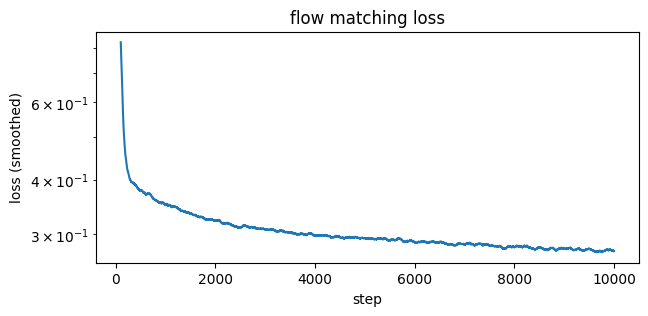

CPU times: user 3min 35s, sys: 873 ms, total: 3min 36s
Wall time: 3min 39s


In [15]:
%%time
losses = train()
# Smoothed loss curve (raw loss is noisy because every batch has different t's)
k = 100
smooth = torch.tensor(losses).unfold(0, k, 1).mean(dim=1)
plt.figure(figsize=(7, 3)); plt.plot(range(k - 1, len(losses)), smooth)
plt.xlabel('step'); plt.ylabel('loss (smoothed)'); plt.yscale('log'); plt.title('flow matching loss'); plt.show()

## 6. Generate: Euler → Euler–Maruyama
To fold a new sequence: start from noise at `t = 0` and follow the predicted velocity to `t = 1`.
Simplest possible sampler first: plain Euler, `x += v * dt`.

In [16]:
@torch.no_grad()
def generate_euler(seq): # the simplest sampler: just follow the velocity field
    x = torch.randn(seq.shape[0], L, 3, device=seq.device)  # (B, L, 3) pure noise
    dt = 1.0 / SAMPLE_STEPS
    for i in range(SAMPLE_STEPS):
        t = torch.full((seq.shape[0],), i * dt, device=seq.device)  # (B,) the same t for every structure in the batch
        x = x - x.mean(dim=1, keepdim=True)  # keep the structure centered (training data was always centered)
        x = x + model(seq, x, t) * dt        # one Euler step along the predicted velocity
    return x * SCALE                         # back to Angstroms

n_eval = min(1000, len(test_seq))       # score on 1000 held-out fragments from proteins never seen in training
seq, true = test_seq[:n_eval].to(device), test_xyz[:n_eval]
pred_euler = generate_euler(seq).cpu()
print(f"Euler: lDDT {avg(lddt, pred_euler, true):.3f}, dRMSD {avg(drmsd, pred_euler, true):.2f} A")

Euler: lDDT 0.560, dRMSD 4.33 A


Not great. The learned $v$ is an *average* over all the straight lines passing through
a point, so small errors compound step after step. **Euler–Maruyama** (an SDE sampler, as in SimpleFold) fixes this:
at every step, remove the model's estimate of the noise and add back a little fresh, clean Gaussian noise. Early on
(blurry structure) correct aggressively; near the end, back off so fine detail survives.

From $x_t = t\,x_1 + (1-t)\,x_0$ and $v = x_1 - x_0$, the model's guess of the noise is $x_0 \approx x - t\,v$.

In [17]:
### Generation: Euler-Maruyama sampler ###
@torch.no_grad()
def generate(seq, return_traj=False): # seq: (B, L) amino-acid ids. Returns (B, L, 3) coordinates in Angstroms.
    x = torch.randn(seq.shape[0], L, 3, device=seq.device)  # (B, L, 3) pure noise
    dt = 1.0 / SAMPLE_STEPS
    traj = []                                    # (for the animation below; not in picofold.py)
    for i in range(SAMPLE_STEPS):
        t = i * dt
        x = x - x.mean(dim=1, keepdim=True)          # keep the structure centered
        v = model(seq, x, torch.full((seq.shape[0],), t, device=seq.device))  # (B, L, 3)
        if t < 0.99:
            noise_guess = x - t * v                  # (B, L, 3) the model's guess of the noise in x
            score = -noise_guess / (1 - t)           # (B, L, 3) points toward less noisy structures
            w = (1 - t) / (t + 0.01)                 # scalar correction strength: big early, small late
            # Euler-Maruyama: x += drift*dt + diffusion*sqrt(dt)*randn, drift = v + w*score, diffusion = sqrt(2*w*TAU)
            x = x + (v + w * score) * dt + math.sqrt(2 * dt * w * TAU) * torch.randn_like(x)
        else:
            x = x + v * dt                           # last few steps: plain Euler (1/(1-t) would blow up)
        if return_traj and i % 5 == 0:
            traj.append((x - x.mean(dim=1, keepdim=True)) * SCALE)
    return (x * SCALE, traj) if return_traj else x * SCALE  # (B, L, 3) in Angstroms

pred = generate(seq).cpu()
print(f"{'':22s} {'lDDT ↑':>8s} {'dRMSD ↓':>9s}")
print(f"{'Euler':22s} {avg(lddt, pred_euler, true):8.3f} {avg(drmsd, pred_euler, true):7.2f} A")
print(f"{'Euler-Maruyama':22s} {avg(lddt, pred, true):8.3f} {avg(drmsd, pred, true):7.2f} A")

                         lDDT ↑   dRMSD ↓
Euler                     0.560    4.33 A
Euler-Maruyama            0.616    3.88 A


In [18]:
# Animate one test fragment folding from noise (index 6 is a helix in the true structure)
i = 6
s = test_seq[i:i + 1].to(device)
final, traj = generate(s, return_traj=True)
frames = [f[0].cpu() for f in traj] + [final[0].cpu() - final[0].cpu().mean(0)]  # one (L, 3) snapshot per 5 steps

# The generated structure comes out in a random orientation (training used random rotations), so we don't try to
# overlay it on the truth: the true structure just sits off to the side for comparison. Drag to line them up by eye.
truth = ca_trace(true[i] - true[i].mean(0) + torch.tensor([30.0, 0, 0]), test_seq[i], 'true', 'lightgray')
fig = go.Figure([truth, ca_trace(frames[0], test_seq[i], 'generated', 'crimson')],
                frames=[go.Frame(data=[truth, ca_trace(f, test_seq[i], 'generated', 'crimson')], name=str(k))
                        for k, f in enumerate(frames)])
fig.update_layout(title=f"Folding {decode(test_seq[i].tolist())} (grey = true structure)", height=500,
                  scene=dict(aspectmode='manual', aspectratio=dict(x=2, y=1, z=1),   # fixed box so frames don't jump
                             xaxis=dict(range=[-25, 55]), yaxis=dict(range=[-20, 20]), zaxis=dict(range=[-20, 20])),
                  updatemenus=[dict(type='buttons', buttons=[dict(label='▶ fold', method='animate',
                      args=[None, dict(frame=dict(duration=60, redraw=True), fromcurrent=True)])])])
fig.show()
print(f"lDDT of this sample: {lddt(final[0].tolist(), true[i].tolist()):.3f}")  # distances only, so no alignment needed

lDDT of this sample: 0.863


## Wrap-up
That's it - everything above (minus plots and checks) is in [`picofold.py`](https://github.com/daveyburke/picofold/blob/main/picofold.py).

**Where to go next:** longer windows and full chains, all backbone atoms, a mirror-sensitive input feature (the model sometimes builds left-handed helices, and distance-based scores can't see it), more data (e.g. distilled from AlphaFold) and more steps.